In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [3]:
import os

file_path = "../data/processed/Delay_rate_by_state.csv"

if not os.path.exists(file_path):
    print(f"Error: The File '{file_path}' does not exist ")
else:
    try:
        df = pd.read_csv(
            file_path,
            on_bad_lines ="skip",
            encoding = 'utf-8'
        )
        print("CSV loaded successfully")
        print(df.head())
    except pd.errors.EmptyDataError:
        print("Error: The CSV is empty")
    except pd.errors.ParserError as e:
        print(f"Error: Parse error (structrally corrupt CSV) {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        

CSV loaded successfully
  state  total_delivered_orders  delayed_orders  delayed_rate_pct
0    WA                   19941            1964               9.0
1    CA                  234813           23200               9.0
2    CO                   20247            2019               9.0
3    FL                  128960           12705               9.0
4    AZ                   19490            1928               9.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   10 non-null     str    
 1   total_delivered_orders  10 non-null     int64  
 2   delayed_orders          10 non-null     int64  
 3   delayed_rate_pct        10 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 452.0 bytes


In [4]:
df.describe()

,total_delivered_orders,delayed_orders,delayed_rate_pct
count,10.000000,10.000000,10.000000
mean,93374.800000,9204.400000,9.100000
std,72013.758343,7086.066786,0.316228
min,19490.000000,1928.000000,9.000000
25%,29975.500000,2996.000000,9.000000
50%,78378.500000,7716.000000,9.000000
75%,126037.250000,12411.000000,9.000000
max,234813.000000,23200.000000,10.000000


In [6]:
df.isna().sum()

state                     0
total_delivered_orders    0
delayed_orders            0
delayed_rate_pct          0
dtype: int64

In [11]:
df.rename(columns={'total_delivered_orders':'delivered_orders','delayed_rate_pct':'delay_rate'},inplace=True)

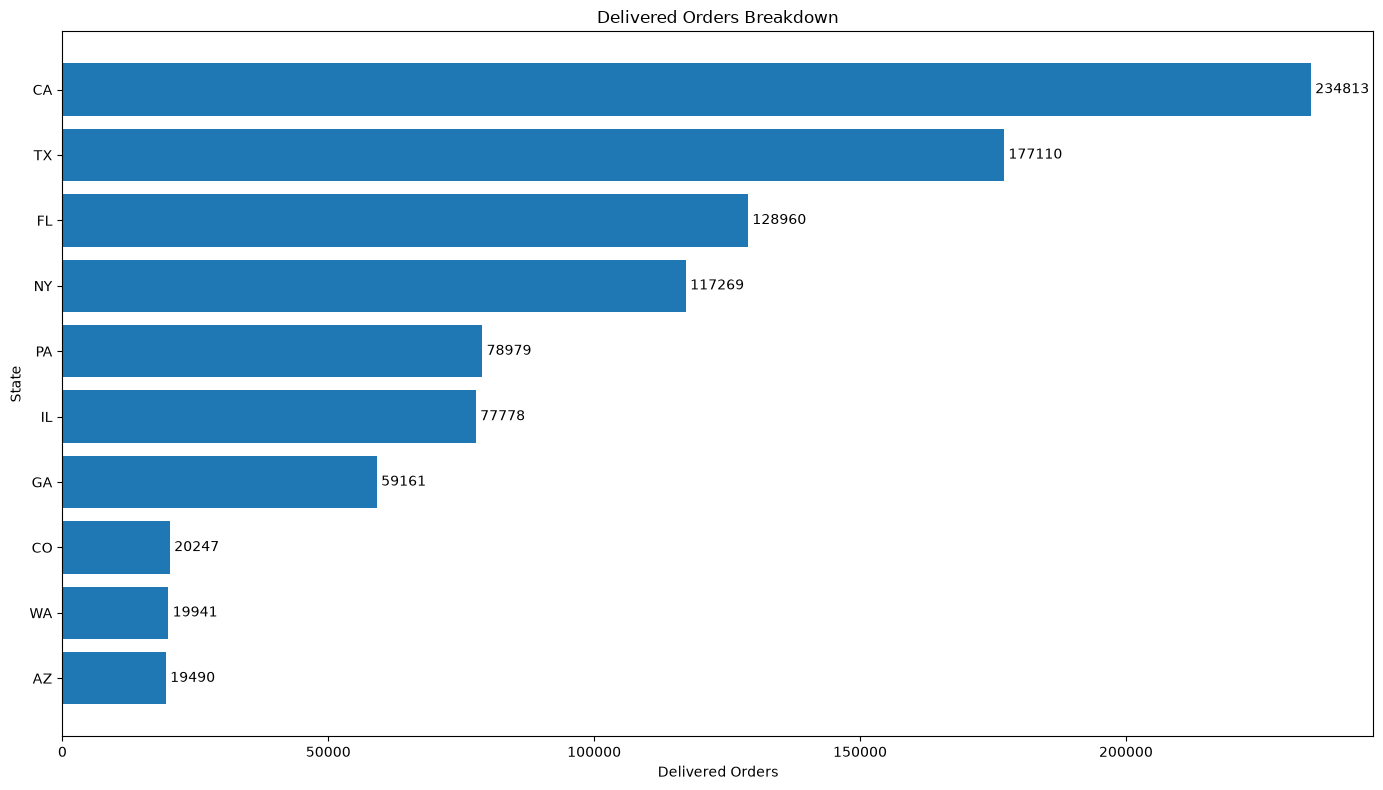

In [13]:
df = df.sort_values(by='delivered_orders')
fig,ax = plt.subplots(figsize=(14,8))

bars = ax.barh(df['state'],df['delivered_orders'])

ax.bar_label(bars,padding=3)

ax.set_xlabel('Delivered Orders')
ax.set_ylabel('State')
ax.set_title('Delivered Orders Breakdown')

plt.tight_layout()
plt.show()


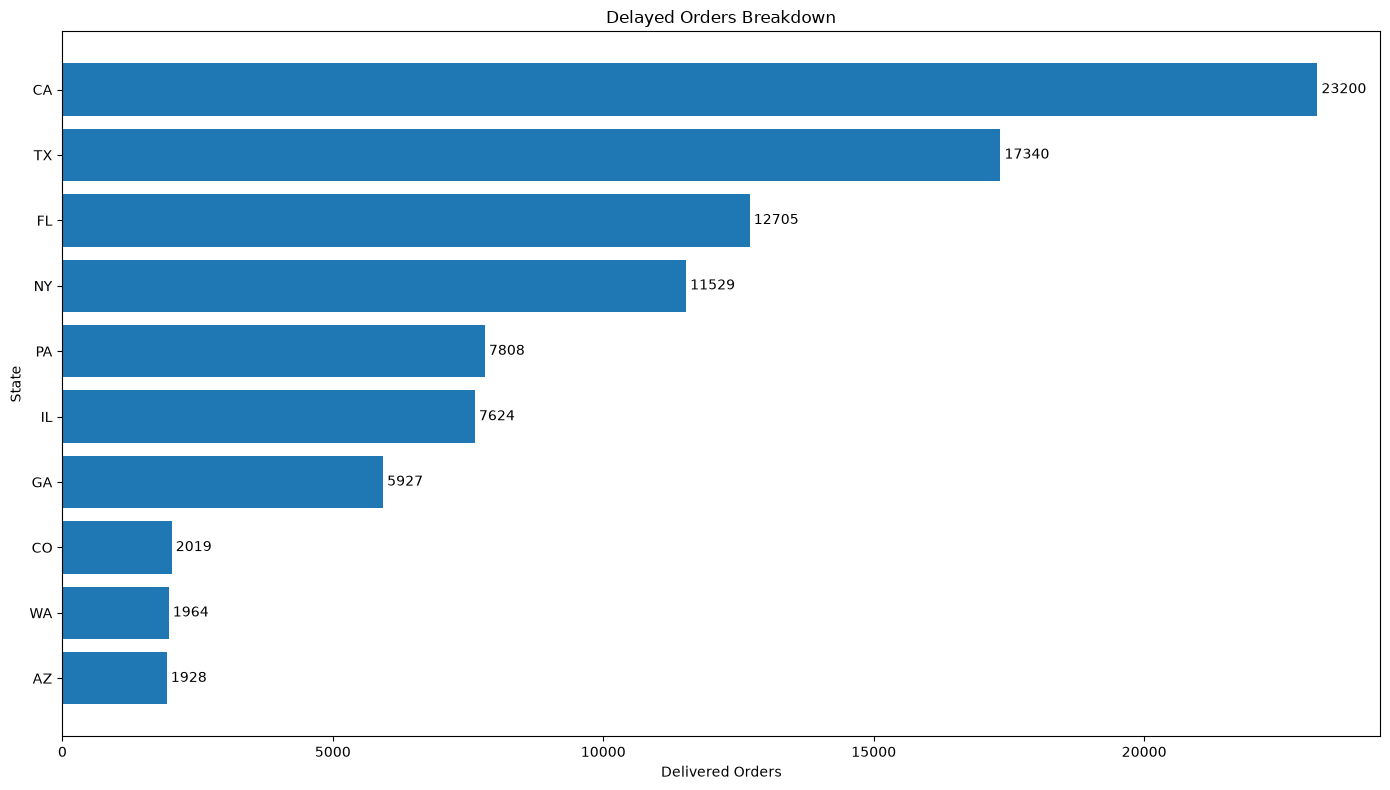

In [15]:
df = df.sort_values(by='delayed_orders')
fig,ax = plt.subplots(figsize=(14,8))

bars = ax.barh(df['state'],df['delayed_orders'])

ax.bar_label(bars,padding=3)

ax.set_xlabel('Delivered Orders')
ax.set_ylabel('State')
ax.set_title('Delayed Orders Breakdown')

plt.tight_layout()
plt.show()

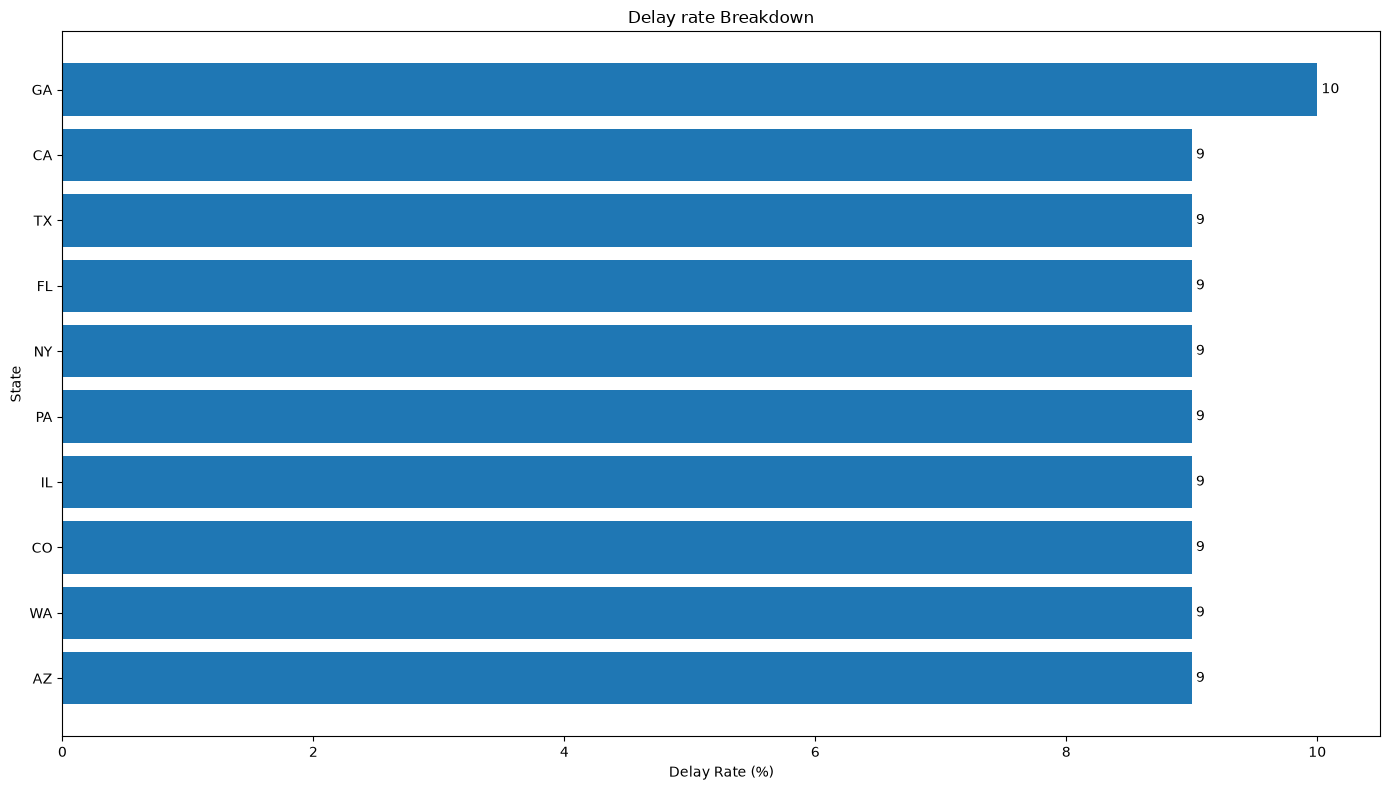

In [17]:
df = df.sort_values(by='delay_rate')
fig,ax = plt.subplots(figsize=(14,8))

bars = ax.barh(df['state'],df['delay_rate'])

ax.bar_label(bars,padding=3)

ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('State')
ax.set_title('Delay rate Breakdown')

plt.tight_layout()
plt.show()